<a href="https://colab.research.google.com/github/ThiagoCalazansLuzNakano/CP_2_Soluces_Renovaveis/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [76]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [77]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [78]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


Execute a célula abaixo. Caso a conexão com a API falhe, pule para a etapa dos imports

In [79]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [80]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [81]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


##Imports necessários para as tarefas:

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [83]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [84]:
df = pd.read_csv('/content/aneel_classificacao_orange.csv')
df.head(20)


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


In [85]:
# X representa as tres entradas que sao mostradas na tabela.
# Essas entradas sao potencia_kw, latitude e longitude.
# Já o y, representa o resultado que queremos prever, que é a fonte de geração,
# podendo ser Solar, Eólica ou Hidráulica.

In [86]:
df.columns

Index(['potencia_kw', 'latitude', 'longitude', 'fonte'], dtype='object')

In [87]:
X = df.drop('fonte', axis=1)
y = df['fonte']

print(y)
print(X)

0            Solar
1            Solar
2            Solar
3            Solar
4            Solar
           ...    
3871    Hidráulica
3872    Hidráulica
3873    Hidráulica
3874    Hidráulica
3875    Hidráulica
Name: fonte, Length: 3876, dtype: object
      potencia_kw   latitude  longitude
0           20.48 -10.442778 -64.151944
1         5000.00  -6.003889 -40.274722
2           12.26 -23.557778 -46.734000
3            3.00 -23.558889 -46.735000
4            1.70 -23.493819 -46.845000
...           ...        ...        ...
3871      2000.00   0.000000   0.000000
3872      1500.00   0.000000   0.000000
3873       710.00   0.000000   0.000000
3874       297.50   0.000000   0.000000
3875      1400.00   0.000000   0.000000

[3876 rows x 3 columns]


In [88]:
SEMENTE = 42
colunas_X = ["potencia_kw", "latitude", "longitude"]
X = df[colunas_X]
y = df["fonte"]

In [89]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMENTE
)

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ALTERADO: removidos os imports do sklearn (só usados a partir da parte 6)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

url = "https://raw.githubusercontent.com/prof-atritiack/CP2-ML-SERS/refs/heads/main/Data_for_UCI_named.csv"
df = pd.read_csv(url)  # ALTERADO: seções 1 e 2 juntadas numa célula só, sem o df.head()

In [91]:
# Definição da variável target y
y = df['stab']
display(y.head())

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


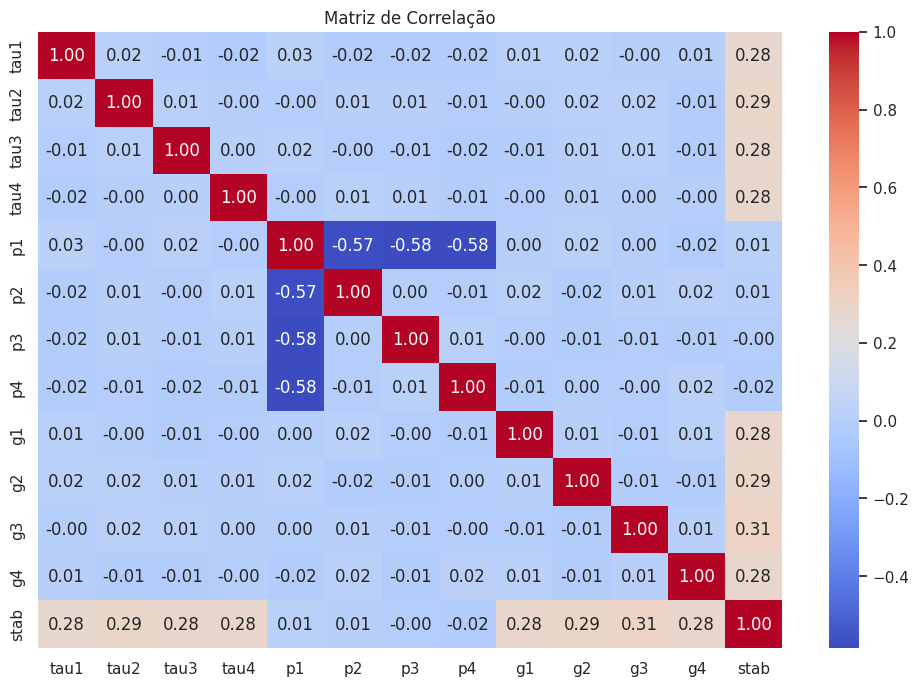

In [92]:
# Cálculo da matriz de correlação das variáveis numéricas
correlacao = df.select_dtypes(include=[np.number]).corr()

# Exibição do mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

As cinco variáveis selecionadas são: ['g3', 'g2', 'tau2', 'g1', 'tau3']
g3: correlação original = 0.3082
g2: correlação original = 0.2936
tau2: correlação original = 0.2910
g1: correlação original = 0.2828
tau3: correlação original = 0.2807


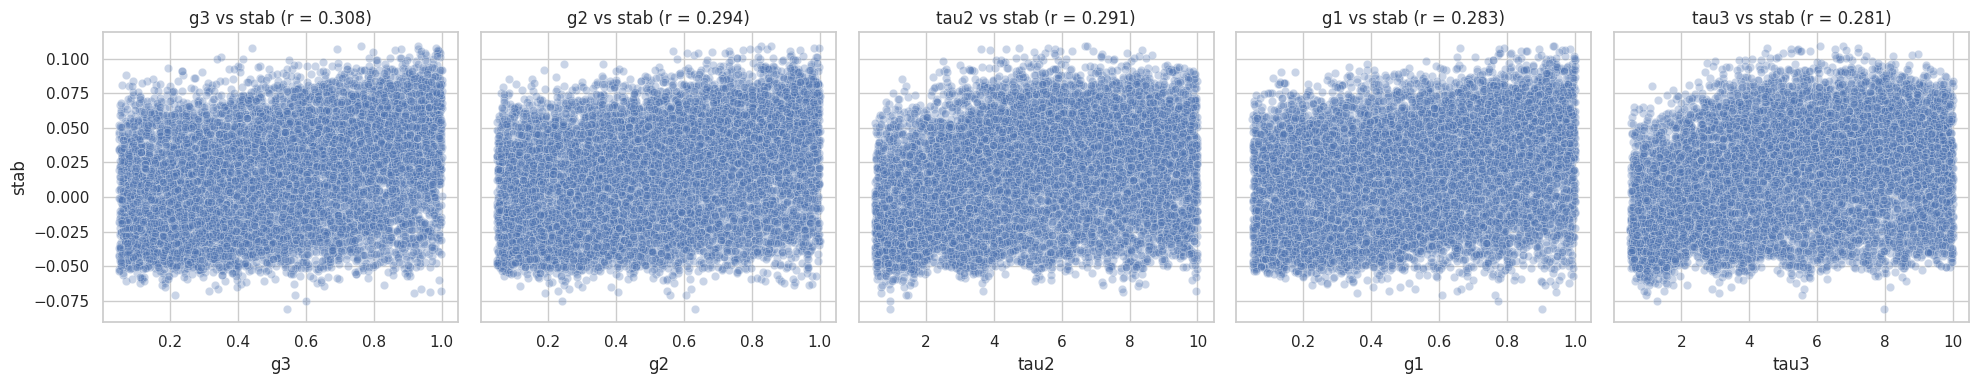

In [93]:
# (1) e (2) Correlação das variáveis numéricas com stab, sem a própria stab
corr_stab = correlacao['stab'].drop('stab')

# (3) Cinco maiores correlações em valor absoluto
cinco_variaveis = corr_stab.abs().nlargest(5).index.tolist()

# (4) Nomes e valores originais (com sinal)
print("As cinco variáveis selecionadas são:", cinco_variaveis)
for col in cinco_variaveis:
    print(f"{col}: correlação original = {corr_stab[col]:.4f}")

# (6) Gráficos de dispersão (variável no eixo X, stab no eixo Y)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, col in enumerate(cinco_variaveis):
    sns.scatterplot(data=df, x=col, y='stab', ax=axes[i], alpha=0.3)
    axes[i].set_title(f"{col} vs stab (r = {corr_stab[col]:.3f})")  # ALTERADO: antes era f"{col} vs stab" (agora mostra também o valor de r)
plt.tight_layout()
plt.show()

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [94]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [95]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [96]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [97]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [98]:
regr = pd.read_csv("/content/meteo_regressao_orange.csv")

regr["data_hora"] = pd.to_datetime(regr["data_hora"])
regr = regr.sort_values("data_hora").reset_index(drop=True)
# valores ausentes
print(regr.shape)
print("Horas duplicadas:", regr["data_hora"].duplicated().sum())

(1001, 7)
Horas duplicadas: 0


 Explicação das colunas:

- data_hora: carimbo de data/hora (ISO, resolução horária). Serve só para ordenar e dividir; não entra como entrada.
- temperatura_c: temperatura do ar (°C).
- umidade_pct: umidade relativa (%).
- nuvens_pct: cobertura de nuvens (%).
- vento_kmh: velocidade do vento (km/h).
- hora: hora do dia (0 a 23), extraída de data_hora.
radiacao_w_m2: radiação solar (W/m²), o alvo y.

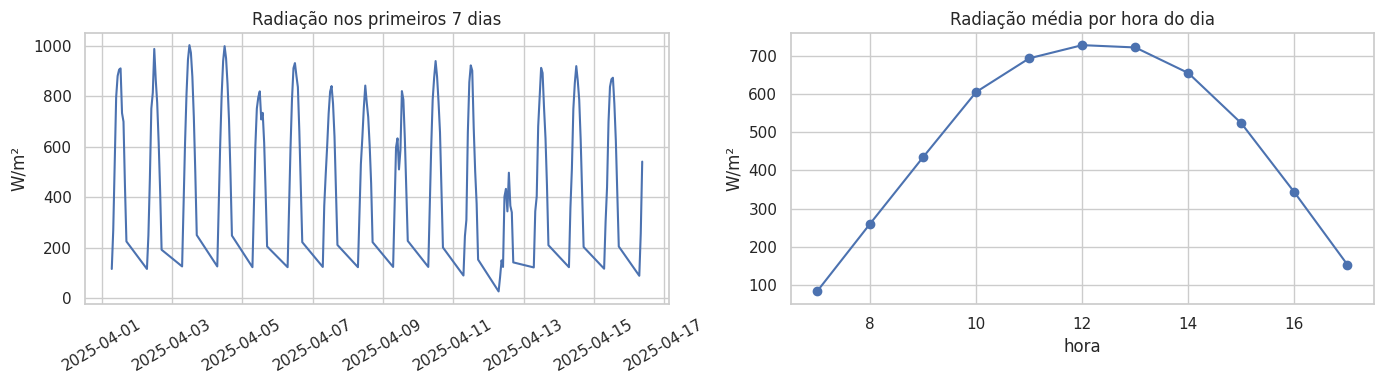

umidade_pct     -0.596183
vento_kmh       -0.229388
nuvens_pct      -0.180196
hora             0.120143
temperatura_c    0.642733
radiacao_w_m2    1.000000
Name: radiacao_w_m2, dtype: float64


In [99]:
# visualização
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Primeiros 7 dias
sub = regr.iloc[:24*7]
ax[0].plot(sub["data_hora"], sub["radiacao_w_m2"])
ax[0].set_title("Radiação nos primeiros 7 dias")
ax[0].set_ylabel("W/m²"); ax[0].tick_params(axis="x", rotation=30)

# Radiação média por hora do dia
regr.groupby("hora")["radiacao_w_m2"].mean().plot(ax=ax[1], marker="o")
ax[1].set_title("Radiação média por hora do dia")
ax[1].set_ylabel("W/m²"); ax[1].set_xlabel("hora")
plt.tight_layout(); plt.show()

# Correlações
print(regr.drop(columns="data_hora").corr()["radiacao_w_m2"].sort_values())

In [100]:
# Definição de X e y
features = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X2 = regr[features]
y2 = regr["radiacao_w_m2"]

In [101]:
# Divisão(80/20)
corte = int(len(regr) * 0.8)
X2_train, X2_test = X2.iloc[:corte], X2.iloc[corte:]
y2_train, y2_test = y2.iloc[:corte], y2.iloc[corte:]

print("Treino:", regr["data_hora"].iloc[0], "->", regr["data_hora"].iloc[corte-1])
print("Teste: ", regr["data_hora"].iloc[corte], "->", regr["data_hora"].iloc[-1])

Treino: 2025-04-01 07:00:00 -> 2025-06-12 14:00:00
Teste:  2025-06-12 15:00:00 -> 2025-06-30 17:00:00


In [102]:
# Três algoritmos de regressão diferentes
med = X2_train.median()
X2_train = X2_train.fillna(med)
X2_test = X2_test.fillna(med)

modelos = {
    "Regressão Linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                           random_state=42, n_jobs=-1),}

resultados, previsoes = [], {}
for nome, modelo in modelos.items():
    modelo.fit(X2_train, y2_train)
    pred = modelo.predict(X2_test)
    previsoes[nome] = pred
    resultados.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y2_test, pred),
        "MSE ((W/m²)²)": mean_squared_error(y2_test, pred),
        "R²": r2_score(y2_test, pred),
   })
tabela = pd.DataFrame(resultados).set_index("Modelo").round(3)
tabela

,MAE (W/m²),MSE ((W/m²)²),R²
Modelo,,,
Regressão Linear,145.205,30034.201,0.360
Decision Tree,84.493,13089.783,0.721
Random Forest,69.277,7859.748,0.832


Justificativas:

Regressão Linear: baseline simples e interpretável; deve ir pior porque a radiação tem perfil em sino ao longo do dia (relação não linear com hora).
Decision Tree: captura não linearidades e interações (hora × nuvens) por regras; limitei max_depth e min_samples_leaf para evitar sobreajuste, mas sozinha ainda é instável e gera previsões em degraus.
Random Forest: média de várias árvores; reduz a variância da árvore única e tende a generalizar melhor.

Melhor modelo (menor MAE): Random Forest


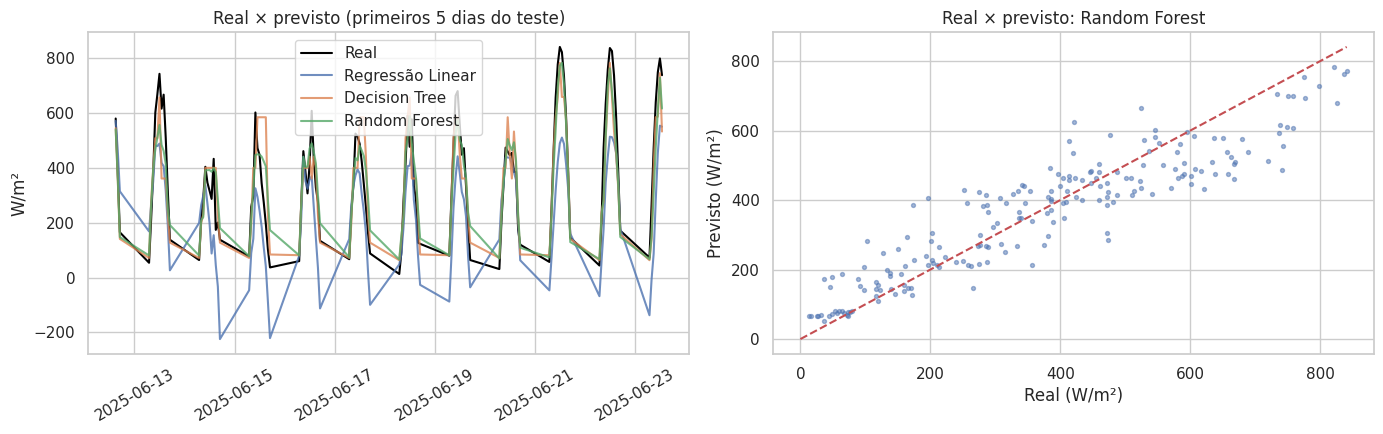

In [103]:
# Comparação e grafico
melhor = tabela["MAE (W/m²)"].idxmin()
print("Melhor modelo (menor MAE):", melhor)

datas_teste = regr["data_hora"].iloc[corte:].reset_index(drop=True)
n = 24 * 5

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].plot(datas_teste[:n], y2_test.values[:n], label="Real", color="black")
for nome, p in previsoes.items():
    ax[0].plot(datas_teste[:n], p[:n], alpha=.8, label=nome)
ax[0].set_title("Real × previsto (primeiros 5 dias do teste)")
ax[0].set_ylabel("W/m²")
ax[0].legend()
ax[0].tick_params(axis="x", rotation=30)

ax[1].scatter(y2_test, previsoes[melhor], s=8, alpha=.5)
lim = [0, max(y2_test.max(), previsoes[melhor].max())]
ax[1].plot(lim, lim, "r--")
ax[1].set_title(f"Real × previsto: {melhor}")
ax[1].set_xlabel("Real (W/m²)")
ax[1].set_ylabel("Previsto (W/m²)")

plt.tight_layout()
plt.show()

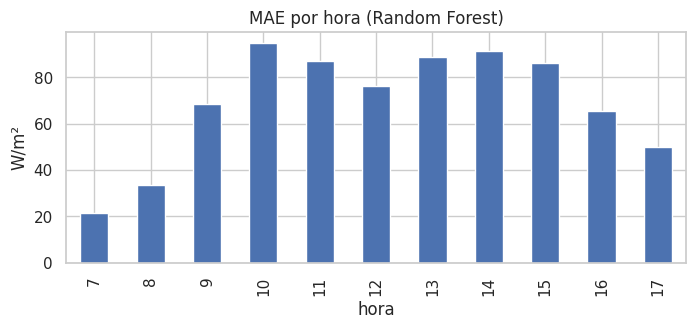

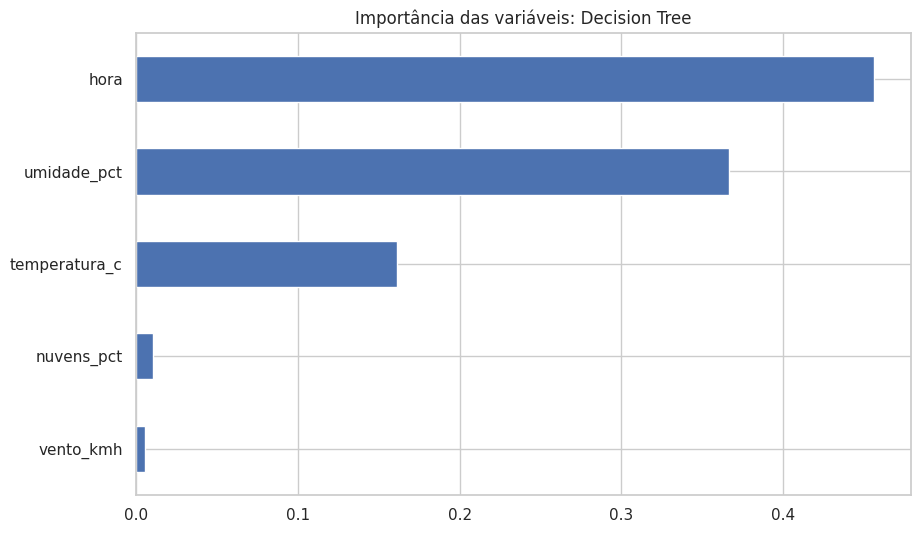

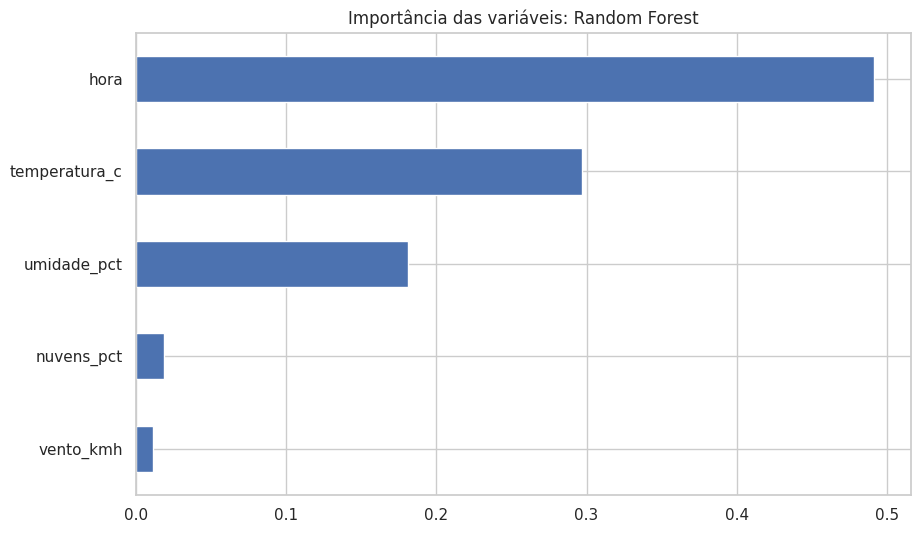

,MAE com hora,MAE sem hora,R² com hora,R² sem hora
Modelo,,,,
Regressão Linear,145.205,145.694,0.360,0.307
Decision Tree,84.493,146.129,0.721,0.176
Random Forest,69.277,131.103,0.832,0.341


In [104]:
# 5a. Erro absoluto médio por hora do dia (melhor modelo)
err = pd.DataFrame({"hora": X2_test["hora"].values,
                    "erro_abs": np.abs(y2_test.values - previsoes[melhor])})
err.groupby("hora")["erro_abs"].mean().plot(kind="bar", figsize=(8, 3),
                                            title=f"MAE por hora ({melhor})")
plt.ylabel("W/m²")
plt.show()
# 5b. Importância das variáveis nos modelos de árvore
for nome in ["Decision Tree", "Random Forest"]:
    imp = pd.Series(modelos[nome].feature_importances_, index=features).sort_values()
    imp.plot(kind="barh", title=f"Importância das variáveis: {nome}")
    plt.show()
# 5c. Teste direto do peso da hora: retreinar SEM 'hora'
f2 = [f for f in features if f != "hora"]
novos = {
    "Regressão Linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                           random_state=42, n_jobs=-1),
}
comp = []
for nome, m in novos.items():
    m.fit(X2_train[f2], y2_train)
    p = m.predict(X2_test[f2])
    comp.append({"Modelo": nome,
                 "MAE com hora": tabela.loc[nome, "MAE (W/m²)"],
                 "MAE sem hora": mean_absolute_error(y2_test, p),
                 "R² com hora": tabela.loc[nome, "R²"],
                 "R² sem hora": r2_score(y2_test, p)})
pd.DataFrame(comp).set_index("Modelo").round(3)

**Erros.** A Random Forest teve o melhor desempenho (MAE = 69,28 W/m², MSE = (W/m²)², R² = 0,832), seguida pela Decision Tree (MAE = 84,49; R² = 0,721) e pela Regressão Linear (MAE = 145,21; R² = 0,360). A Regressão Linear foi a pior porque a radiação tem formato de sino ao longo do dia, e um modelo linear não representa essa relação com hora.

**Peso da hora.** hora é a variável mais importante, pois define o ângulo do sol e o ciclo diário (zero à noite, pico perto do meio-dia). Ao retreinar sem ela, o MAE da Random Forest subiu de 69,28 para 131,10 W/m² (cerca de 89%) e o R² caiu de 0,832 para 0,341. Na Decision Tree, o MAE subiu de 84,49 para 146,13 e o R² caiu de 0,721 para 0,176. Na Regressão Linear quase não houve mudança (145,21 para 145,69), porque ela já não conseguia aproveitar a hora.

**Radiação ≠ energia fotovoltaica.** O modelo estima apenas a radiação solar em W/m². A energia gerada depende também da inclinação e orientação dos painéis, da eficiência do módulo e do inversor, da temperatura da célula, de sombreamento e sujeira, e da área e potência instalada. Por isso, para chegar a kWh é preciso um modelo de conversão ou dados reais de geração.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)